Importing libratries and reading dataset into Pandas Dataframe.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_csv('../train.csv')

Exploring dataset with info, describe methods.

In [21]:
data.head()
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 40.5 MB


,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [22]:
data.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

Explore columns with box plot and histogram and countplot.

<Axes: xlabel='Annual_Premium'>

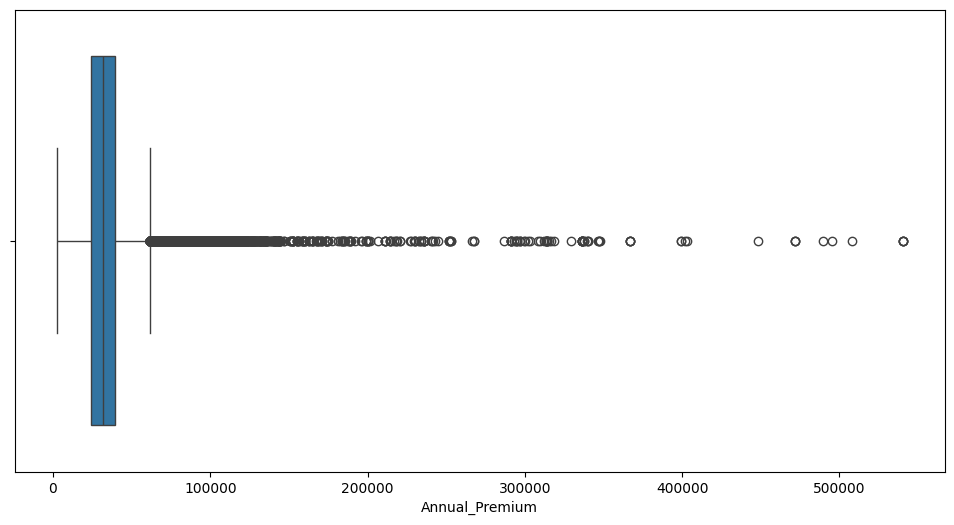

In [23]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='Annual_Premium',data=data)

Text(0.5, 1.0, 'Distribution of Response')

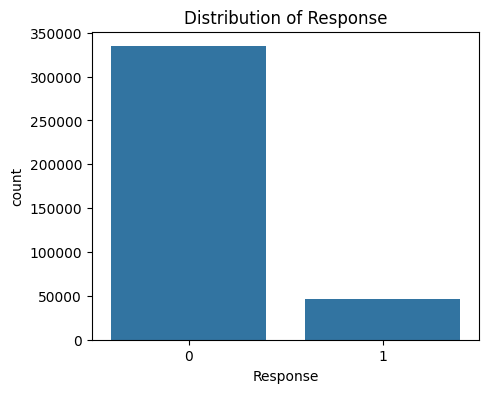

In [24]:

plt.figure(figsize=(5, 4))
sns.countplot(x='Response',data=data)
plt.title("Distribution of Response")

Text(0.5, 1.0, 'Age vs Vehicle Damage')

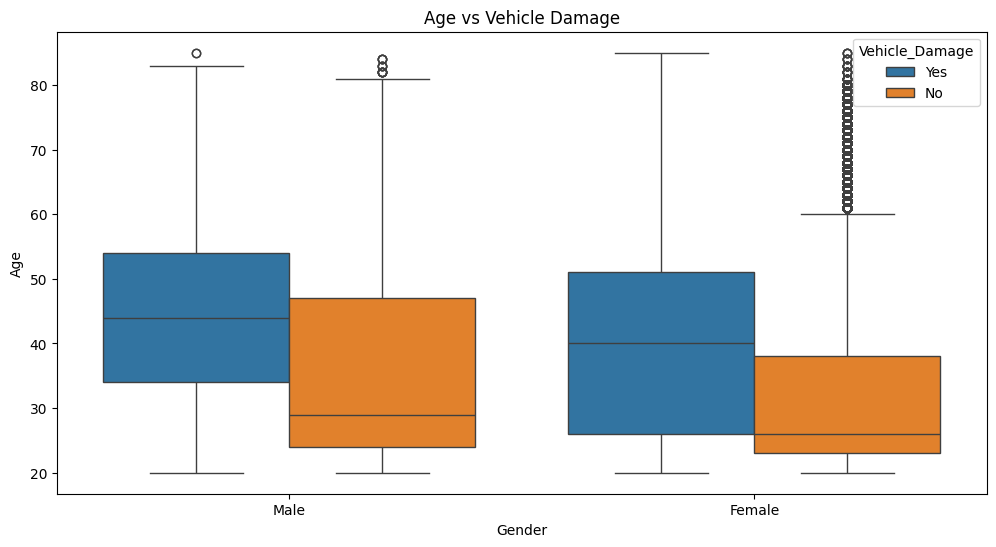

In [25]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='Gender',y='Age',hue='Vehicle_Damage',data=data,legend=True)
plt.title('Age vs Vehicle Damage')

Hypothesis 1:
Previously Insured people are most likely to respond yes.

In [26]:
ct = pd.crosstab(data['Previously_Insured'], data['Response'], normalize='index') * 100

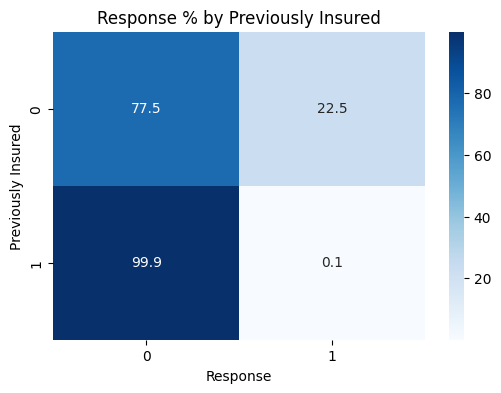

In [27]:
plt.figure(figsize=(6,4))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Response % by Previously Insured")
plt.ylabel("Previously Insured")
plt.xlabel("Response")
plt.show()

Text(0.5, 1.0, 'Previously Insured vs Response')

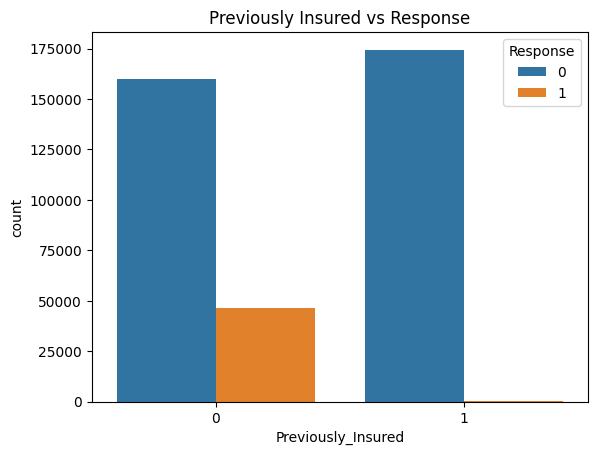

In [28]:
sns.countplot(x='Previously_Insured', hue='Response', data=data)
plt.title("Previously Insured vs Response")

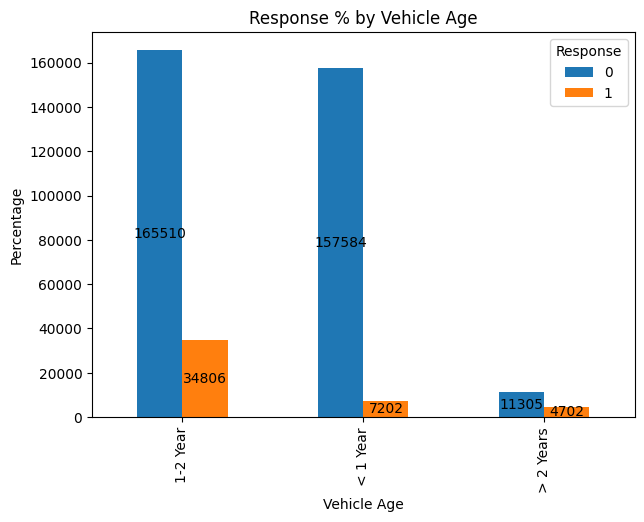

In [29]:
# Step 1: Create crosstab in percentage form
#ct_VehicleAge = pd.crosstab(data['Vehicle_Age'], data['Response'], normalize='index') * 100
ct_VehicleAge = pd.crosstab(data['Vehicle_Age'], data['Response'])
# Step 2: Plot
ax = ct_VehicleAge.plot(kind='bar', figsize=(7,5))

plt.title("Response % by Vehicle Age")
plt.ylabel("Percentage")
plt.xlabel("Vehicle Age")
plt.legend(title="Response")
for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.legend(title="Response")
plt.show()
plt.show()

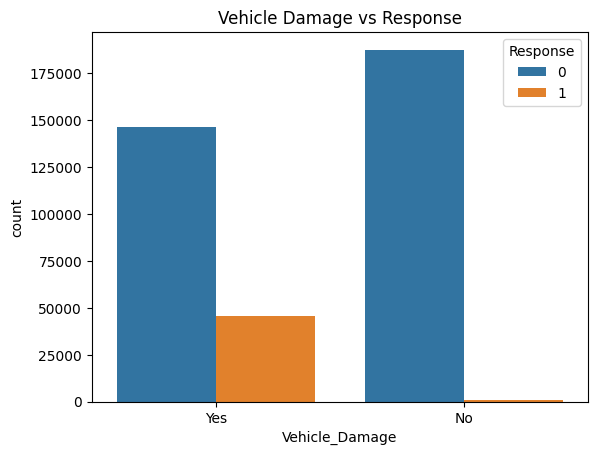

In [30]:
sns.countplot(x='Vehicle_Damage', hue='Response', data=data)
plt.title("Vehicle Damage vs Response")
plt.show()

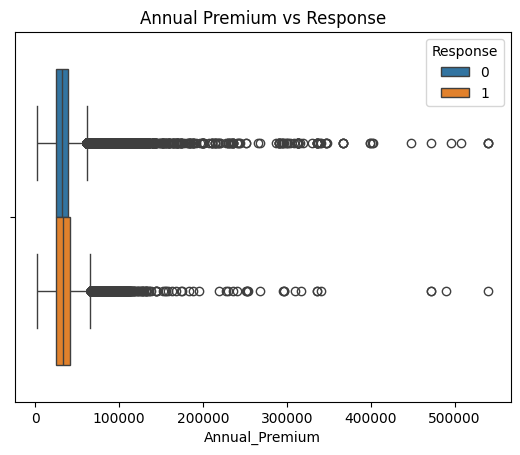

In [31]:
sns.boxplot(x='Annual_Premium', hue='Response', data=data)
plt.title("Annual Premium vs Response")
plt.show()

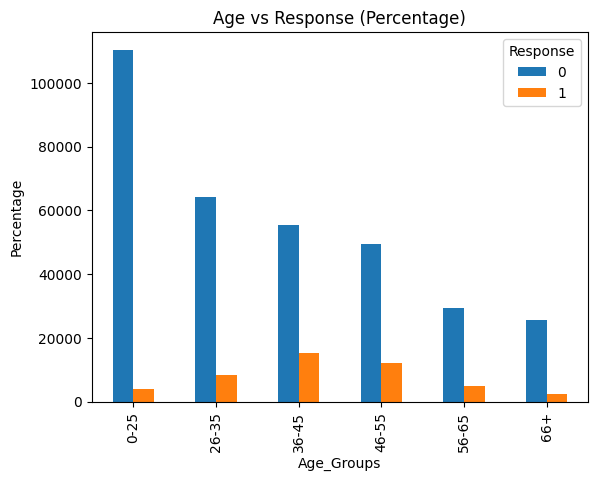

In [32]:
data['Age'].nunique()
data['Age_Groups'] = pd.cut(data['Age'], bins=[0, 25, 35, 45, 55, 65, 100], labels=['0-25', '26-35', '36-45', '46-55', '56-65', '66+'])
#ct = pd.crosstab(data['Age_Groups'], data['Response'], normalize='index')*100
ct = pd.crosstab(data['Age_Groups'], data['Response'])
ax = ct.plot(kind='bar')
plt.ylabel("Percentage")
plt.title("Age vs Response (Percentage)")
# Add labels
#for container in ax.containers:
    #ax.bar_label(container)

plt.show()

In [33]:
data['Driving_License'].value_counts()

Driving_License
1    380297
0       812
Name: count, dtype: int64

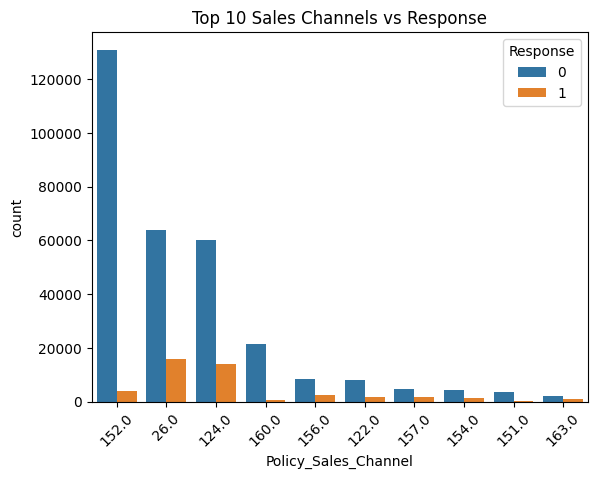

In [34]:
top_channel = data['Policy_Sales_Channel'].value_counts().head(10)
data['Policy_Sales_Channel'].nunique()
filtered = data[data['Policy_Sales_Channel'].isin(top_channel.index)]

sns.countplot(x='Policy_Sales_Channel', hue='Response',data=filtered, order=top_channel.index)
plt.title("Top 10 Sales Channels vs Response")
plt.xticks(rotation=45)
plt.show()

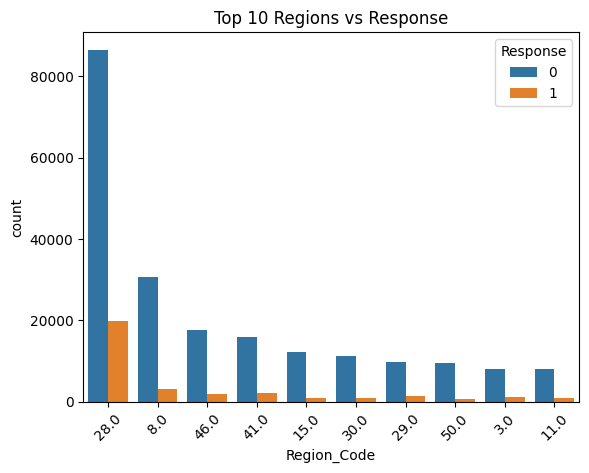

In [35]:
top_regions = data['Region_Code'].value_counts().head(10)

filtered = data[data['Region_Code'].isin(top_regions.index)]

sns.countplot(x='Region_Code',data=filtered, hue='Response',order=top_regions.index)
plt.title("Top 10 Regions vs Response")
plt.xticks(rotation=45)
plt.show()

Split train and test data and convert categorical objects into numerical columns

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('Response', axis=1)
y = data['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=101,
    stratify=y
)

# 2. One-hot encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# 3. Align test set columns with train set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [50]:
X_train.head(2)

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,Vehicle_Age__1_Year,Vehicle_Age__2_Years,Vehicle_Damage_Yes,Age_Groups_26_35,Age_Groups_36_45,Age_Groups_46_55,Age_Groups_56_65,Age_Groups_66_
334356,334357,62,1,28.0,0,50858.0,4.0,203,False,False,False,True,False,False,False,True,False
101284,101285,31,1,15.0,0,34150.0,152.0,12,True,True,False,False,True,False,False,False,False


1. BASELINE MODEL (Logistic Regression)

=== BASELINE MODEL: Logistic Regression ===


c:\Users\suba3\Documents\Greenbootcamps\Insurance-Cross-Sell-Predicton\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


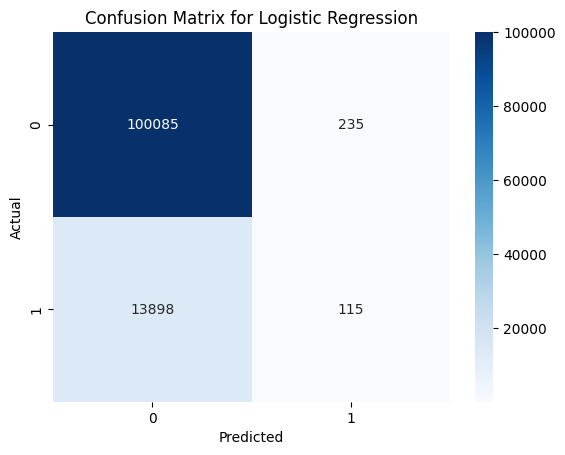

classification_report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    100320
           1       0.33      0.01      0.02     14013

    accuracy                           0.88    114333
   macro avg       0.60      0.50      0.48    114333
weighted avg       0.81      0.88      0.82    114333

ROC-AUC: 0.8381169112049178


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)[:, 1]

print("=== BASELINE MODEL: Logistic Regression ===")
conf_matrix = confusion_matrix(y_test, y_pred_base)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print('classification_report:')
print(classification_report(y_test, y_pred_base))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_base))


2. MODEL 1: Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=101)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

=== RANDOM FOREST ===
[[98492  1828]
 [12877  1136]]
              precision    recall  f1-score   support

           0       0.88      0.98      0.93    100320
           1       0.38      0.08      0.13     14013

    accuracy                           0.87    114333
   macro avg       0.63      0.53      0.53    114333
weighted avg       0.82      0.87      0.83    114333

ROC-AUC: 0.8391335619402625


3. MODEL: Gradient Boosting

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=101)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("=== GRADIENT BOOSTING ===")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

=== GRADIENT BOOSTING ===
[[100306     14]
 [ 14006      7]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    100320
           1       0.33      0.00      0.00     14013

    accuracy                           0.88    114333
   macro avg       0.61      0.50      0.47    114333
weighted avg       0.81      0.88      0.82    114333

ROC-AUC: 0.8553583488947549


Fix column names

In [ ]:
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [56]:
X_train.columns

Index(['id', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Gender_Male',
       'Vehicle_Age__1_Year', 'Vehicle_Age__2_Years', 'Vehicle_Damage_Yes',
       'Age_Groups_26_35', 'Age_Groups_36_45', 'Age_Groups_46_55',
       'Age_Groups_56_65', 'Age_Groups_66_'],
      dtype='str')

4. MODEL XG Boosting

In [41]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=101,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBOOST ===")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

c:\Users\suba3\Documents\Greenbootcamps\Insurance-Cross-Sell-Predicton\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:45:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBOOST ===
[[100291     29]
 [ 13985     28]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    100320
           1       0.49      0.00      0.00     14013

    accuracy                           0.88    114333
   macro avg       0.68      0.50      0.47    114333
weighted avg       0.83      0.88      0.82    114333

ROC-AUC: 0.8574567026704868


In [51]:
y_prob_xgb

array([0.22711645, 0.22807297, 0.16511661, ..., 0.02434943, 0.03181853,
       0.36965   ], shape=(114333,), dtype=float32)

Model comparison table

In [42]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_base),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(results)

                 Model   ROC_AUC
0  Logistic Regression  0.838117
1        Random Forest  0.839134
2    Gradient Boosting  0.855358
3              XGBoost  0.857457


Try to improve Recall with different threshold values.

In [43]:
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [44]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_new = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_new))
    print(classification_report(y_test, y_pred_new))


Threshold: 0.2
[[75484 24836]
 [ 2481 11532]]
              precision    recall  f1-score   support

           0       0.97      0.75      0.85    100320
           1       0.32      0.82      0.46     14013

    accuracy                           0.76    114333
   macro avg       0.64      0.79      0.65    114333
weighted avg       0.89      0.76      0.80    114333


Threshold: 0.3
[[87209 13111]
 [ 6543  7470]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90    100320
           1       0.36      0.53      0.43     14013

    accuracy                           0.83    114333
   macro avg       0.65      0.70      0.67    114333
weighted avg       0.86      0.83      0.84    114333


Threshold: 0.4
[[98562  1758]
 [12602  1411]]
              precision    recall  f1-score   support

           0       0.89      0.98      0.93    100320
           1       0.45      0.10      0.16     14013

    accuracy                           0.

Based on different results threshold 0.3 is finalised for balanced  accuracy and  recall.

In [45]:
y_prob_xgb_final = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb_final = (y_prob_xgb_final >= 0.3).astype(int)

Final Model Evaluation (Threshold = 0.3)


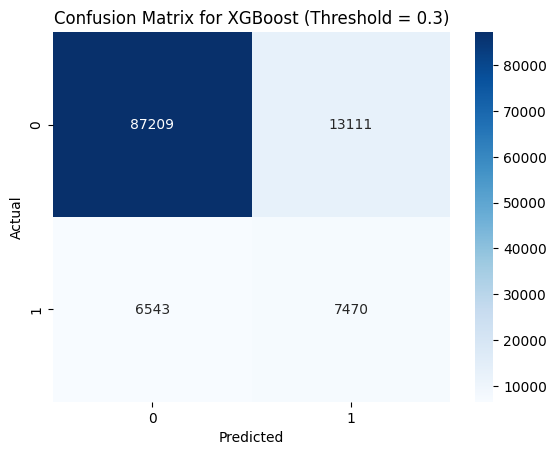

classification_report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90    100320
           1       0.36      0.53      0.43     14013

    accuracy                           0.83    114333
   macro avg       0.65      0.70      0.67    114333
weighted avg       0.86      0.83      0.84    114333

ROC-AUC: 0.8574567026704868


In [46]:
print("Final Model Evaluation (Threshold = 0.3)")
conf_matrix = confusion_matrix(y_test, y_pred_xgb_final)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for XGBoost (Threshold = 0.3)")
plt.show()
print('classification_report:')
print(classification_report(y_test, y_pred_xgb_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

ROC-AUC comparison for all models together.

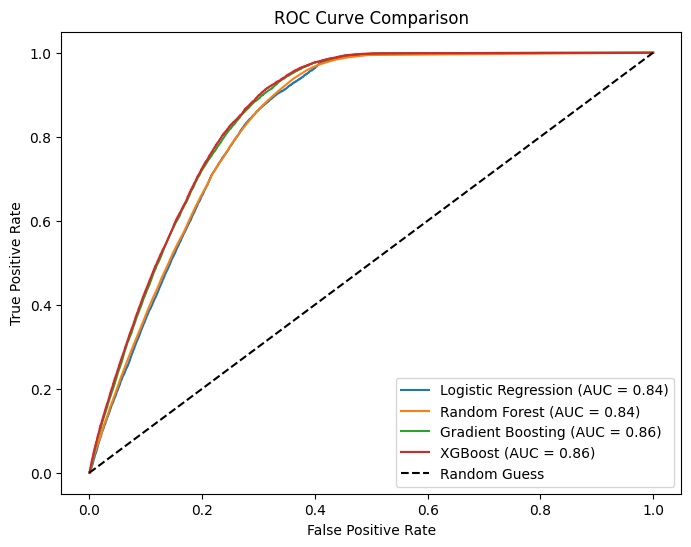

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_base)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_base):.2f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.2f})")

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob_gb):.2f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.2f})")

# Random line (baseline)
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

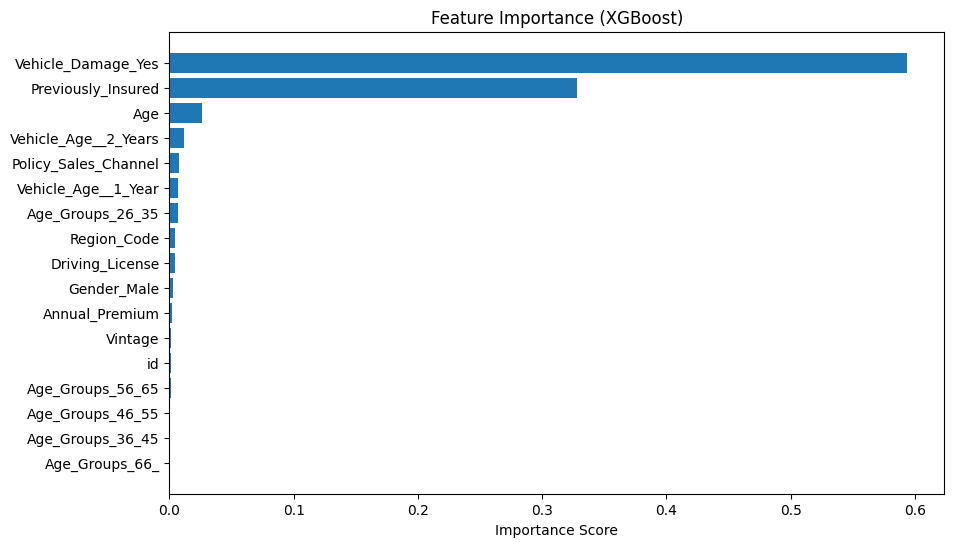

In [48]:
import matplotlib.pyplot as plt

# Get feature importance
importance = xgb_model.feature_importances_
feature_names = X_train.columns

# Create DataFrame
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

In [49]:
X_train.head()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Gender_Male,Vehicle_Age__1_Year,Vehicle_Age__2_Years,Vehicle_Damage_Yes,Age_Groups_26_35,Age_Groups_36_45,Age_Groups_46_55,Age_Groups_56_65,Age_Groups_66_
334356,334357,62,1,28.0,0,50858.0,4.0,203,False,False,False,True,False,False,False,True,False
101284,101285,31,1,15.0,0,34150.0,152.0,12,True,True,False,False,True,False,False,False,False
205719,205720,29,1,13.0,0,2630.0,156.0,161,False,False,False,True,True,False,False,False,False
197742,197743,38,1,20.0,1,2630.0,154.0,80,True,False,False,False,False,True,False,False,False
357839,357840,33,1,11.0,1,32354.0,152.0,191,False,True,False,False,True,False,False,False,False


In [ ]:
import joblib

# ---------------- SAVE MODEL ----------------
joblib.dump(xgb_model, "xgb_model.pkl")

# ---------------- SAVE COLUMNS ----------------
joblib.dump(X_train.columns.tolist(), "columns.pkl")

print("✅ Model and columns saved successfully!")